# 🧬 Supplement Optimization Model - Interactive Demo

This notebook demonstrates how to solve a supplement optimization problem using linear programming. The goal is to find the optimal combination of supplements to minimize cost or pill count while meeting daily nutritional requirements.

## Problem Overview

Given:
- A set of available supplements with different nutritional content and costs
- Daily nutritional requirements for a person
- Objective: Minimize total number of pills OR minimize total cost

This is a variant of the classic "diet problem" in operations research, formulated as a linear programming problem.

## ⚠️ IMPORTANT MEDICAL DISCLAIMER

**🚨 READ THIS BEFORE PROCEEDING 🚨**

**This tool is for educational and research purposes only.** It is NOT intended to provide medical advice, diagnosis, or treatment recommendations.

**ALWAYS consult with a qualified healthcare provider, registered dietitian, or physician before making any changes to your supplement regimen or diet.**

Individual nutritional needs vary based on:
- Age, gender, and life stage
- Health conditions and medical history
- Medications and drug interactions  
- Activity level and lifestyle
- Genetic factors
- Pregnancy, breastfeeding, or other special conditions

**The authors and contributors assume NO RESPONSIBILITY for any health consequences resulting from the use of this tool.** This model cannot account for individual medical needs, contraindications, or supplement interactions.

**By continuing with this notebook, you acknowledge that you understand this is an educational demonstration only and not medical advice.**

In [1]:
# Import required libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from supplement_optimizer import (
    Supplement,
    DailyRequirement, 
    SupplementOptimizer,
    create_sample_data
)

# Set up plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📦 All libraries imported successfully!")
print("🧬 Supplement Optimization Model ready to use")

📦 All libraries imported successfully!
🧬 Supplement Optimization Model ready to use


## 📊 Exploring Sample Data

Let's start by loading and examining the sample supplement data and daily requirements.

In [2]:
# Load sample data
supplements, daily_req = create_sample_data()

print(f"📋 Daily Requirements: {daily_req}")
print(f"🎯 Target nutrients: {len(daily_req.requirements)}")
print(f"💊 Available supplements: {len(supplements)}")
print("\n" + "="*60)
print("🧪 AVAILABLE SUPPLEMENTS:")
print("="*60)

for i, supp in enumerate(supplements, 1):
    print(f"\n{i}. {supp}")
    print(f"   💰 Cost: ${supp.cost_per_unit:.2f} per unit")
    print(f"   🧬 Nutrients:")
    for nutrient, amount in supp.nutrients.items():
        print(f"      • {nutrient}: {amount}")
        
print("\n" + "="*60)
print("🎯 DAILY REQUIREMENTS:")
print("="*60)
for nutrient, amount in daily_req.requirements.items():
    print(f"• {nutrient}: {amount}")

📋 Daily Requirements: Male, age 35
🎯 Target nutrients: 11
💊 Available supplements: 7

🧪 AVAILABLE SUPPLEMENTS:

1. NatureMade Multivitamin (tablet)
   💰 Cost: $0.15 per unit
   🧬 Nutrients:
      • Vitamin A: 900
      • Vitamin C: 90
      • Vitamin D: 20
      • Vitamin E: 15
      • Vitamin B12: 2.4
      • Calcium: 162
      • Iron: 8
      • Magnesium: 100

2. Nordic Naturals Omega-3 (capsule)
   💰 Cost: $0.75 per unit
   🧬 Nutrients:
      • Omega-3 EPA: 325
      • Omega-3 DHA: 225
      • Vitamin E: 5

3. Thorne Magnesium Glycinate (capsule)
   💰 Cost: $0.45 per unit
   🧬 Nutrients:
      • Magnesium: 200

4. Kirkland Calcium + D3 (tablet)
   💰 Cost: $0.08 per unit
   🧬 Nutrients:
      • Calcium: 600
      • Vitamin D: 20

5. Jarrow B12 Sublingual (tablet)
   💰 Cost: $0.12 per unit
   🧬 Nutrients:
      • Vitamin B12: 1000

6. Garden of Life Probiotic (capsule)
   💰 Cost: $1.20 per unit
   🧬 Nutrients:
      • Probiotics: 50

7. Gentle Iron Iron (capsule)
   💰 Cost: $0.18 per 

## 🎯 Optimization Scenarios

Now let's solve the optimization problem using different objectives:
1. **Minimize Pills**: Find the minimum total number of pills/capsules
2. **Minimize Cost**: Find the cheapest supplement combination  
3. **Integer Solutions**: Require whole pills only (no fractional amounts)

In [3]:
# Set up the optimizer
optimizer = SupplementOptimizer()
optimizer.set_daily_requirements(daily_req)

# Add all supplements
for supplement in supplements:
    optimizer.add_supplement(supplement)

# Solve for different objectives
print("🔍 SCENARIO 1: MINIMIZE NUMBER OF PILLS")
print("="*50)
result_pills = optimizer.solve_minimum_pills(allow_fractional=True)
optimizer.print_solution(result_pills)

print("\n\n🔍 SCENARIO 2: MINIMIZE COST") 
print("="*50)
result_cost = optimizer.solve_minimum_cost()
optimizer.print_solution(result_cost)

print("\n\n🔍 SCENARIO 3: MINIMIZE PILLS (WHOLE PILLS ONLY)")
print("="*50) 
result_integer = optimizer.solve_minimum_pills(allow_fractional=False)
optimizer.print_solution(result_integer)

🔍 SCENARIO 1: MINIMIZE NUMBER OF PILLS
✅ Optimal solution found: 5.208 total pills/units

📋 Daily Requirements: Male, age 35
💊 Total Pills/Units: 5.208

📝 Supplement Plan:
  • 1 tablet(s) of NatureMade Multivitamin (tablet)
  • 1.1 capsule(s) of Nordic Naturals Omega-3 (capsule)
  • 1.5 capsule(s) of Thorne Magnesium Glycinate (capsule)
  • 1.4 tablet(s) of Kirkland Calcium + D3 (tablet)
  • 0.2 capsule(s) of Garden of Life Probiotic (capsule)

🔬 Nutrient Analysis:
  • Calcium: 1000.0/1000 (100.0%)
  • Iron: 8.0/8 (100.0%)
  • Magnesium: 400.0/400 (100.0%)
  • Omega-3 DHA: 250.0/250 (100.0%)
  • Omega-3 EPA: 361.111/250 (144.4%) (+111.111 surplus)
  • Probiotics: 10.0/10 (100.0%)
  • Vitamin A: 900.0/900 (100.0%)
  • Vitamin B12: 2.4/2.4 (100.0%)
  • Vitamin C: 90.0/90 (100.0%)
  • Vitamin D: 47.933/15 (319.6%) (+32.933 surplus)
  • Vitamin E: 20.556/15 (137.0%) (+5.556 surplus)


🔍 SCENARIO 2: MINIMIZE COST
✅ Optimal solution found: $1.72 total cost

📋 Daily Requirements: Male, age 35

## 📈 Visualizing Optimization Results

Let's create some charts to better understand the optimization results.

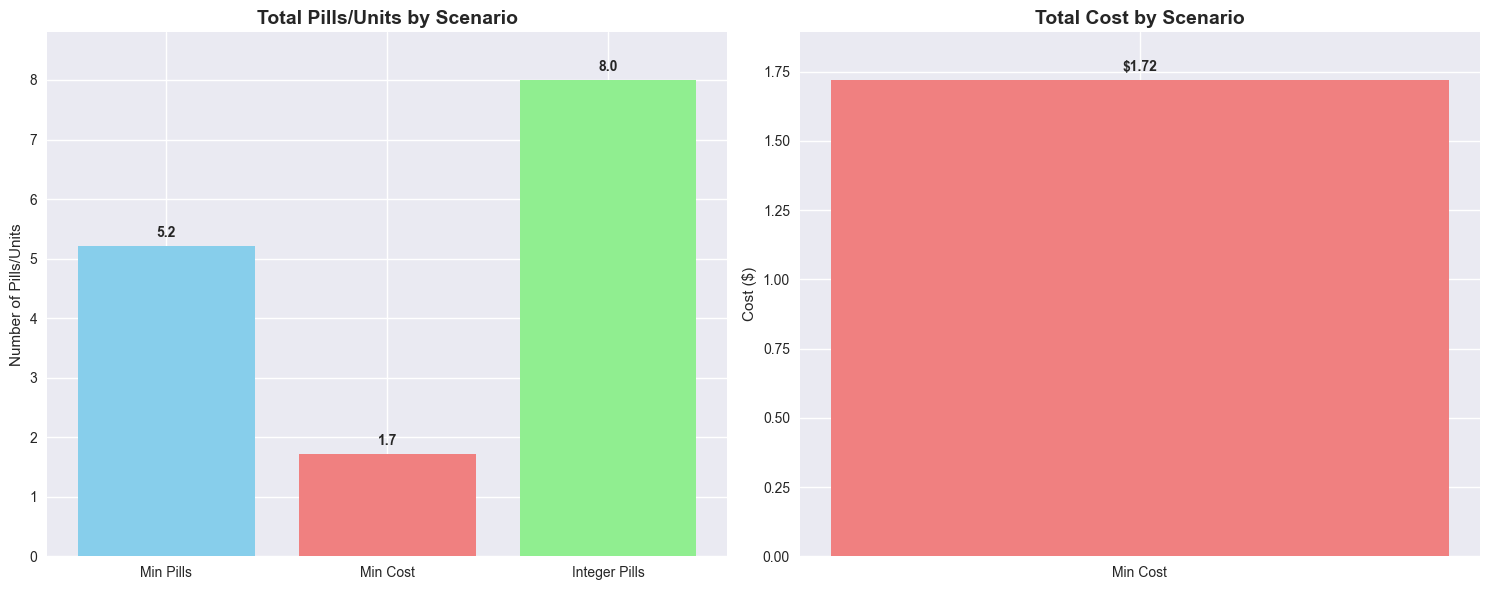

In [11]:
def create_comparison_chart(results_dict):
    """Create a comparison chart of optimization scenarios."""
    scenarios = list(results_dict.keys())
    pill_counts = [results_dict[scenario]['total_pills'] for scenario in scenarios]
    costs = [results_dict[scenario].get('total_cost', 0) for scenario in scenarios]
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Pills comparison
    bars1 = ax1.bar(scenarios, pill_counts, color=['skyblue', 'lightcoral', 'lightgreen'])
    ax1.set_title('Total Pills/Units by Scenario', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Number of Pills/Units')
    ax1.set_ylim(0, max(pill_counts) * 1.1)
    
    # Add value labels on bars
    for bar, value in zip(bars1, pill_counts):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
                f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    # Cost comparison (only for scenarios with cost data)
    cost_scenarios = [s for s, c in zip(scenarios, costs) if c > 0]
    cost_values = [c for c in costs if c > 0]
    
    if cost_values:
        bars2 = ax2.bar(cost_scenarios, cost_values, color=['lightcoral'])
        ax2.set_title('Total Cost by Scenario', fontsize=14, fontweight='bold')
        ax2.set_ylabel('Cost ($)')
        ax2.set_ylim(0, max(cost_values) * 1.1)
        
        # Add value labels on bars
        for bar, value in zip(bars2, cost_values):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                    f'${value:.2f}', ha='center', va='bottom', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'No cost data available', ha='center', va='center', 
                transform=ax2.transAxes, fontsize=12)
        ax2.set_title('Total Cost by Scenario', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

def visualize_nutrient_analysis(result, title="Nutrient Analysis"):
    """Visualize how well requirements are met."""
    if not result['success'] or not result['nutrient_analysis']:
        print("No nutrient analysis data available")
        return
    
    nutrients = [item['nutrient'] for item in result['nutrient_analysis']]
    percentages = [item['percentage_of_requirement'] for item in result['nutrient_analysis']]
    
    plt.figure(figsize=(12, 8))
    colors = ['green' if p >= 100 else 'orange' for p in percentages]
    bars = plt.barh(nutrients, percentages, color=colors, alpha=0.7)
    
    # Add 100% reference line
    plt.axvline(x=100, color='red', linestyle='--', alpha=0.8, label='100% Requirement')
    
    plt.xlabel('Percentage of Daily Requirement Met')
    plt.title(f'{title}: Nutrient Requirements Coverage', fontsize=14, fontweight='bold')
    plt.legend()
    
    # Add percentage labels
    for bar, percentage in zip(bars, percentages):
        plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, 
                f'{percentage:.1f}%', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Create comparisons
results_comparison = {
    'Min Pills': result_pills,
    'Min Cost': result_cost, 
    'Integer Pills': result_integer
}

create_comparison_chart(results_comparison)

🔬 Nutrient Coverage Analysis


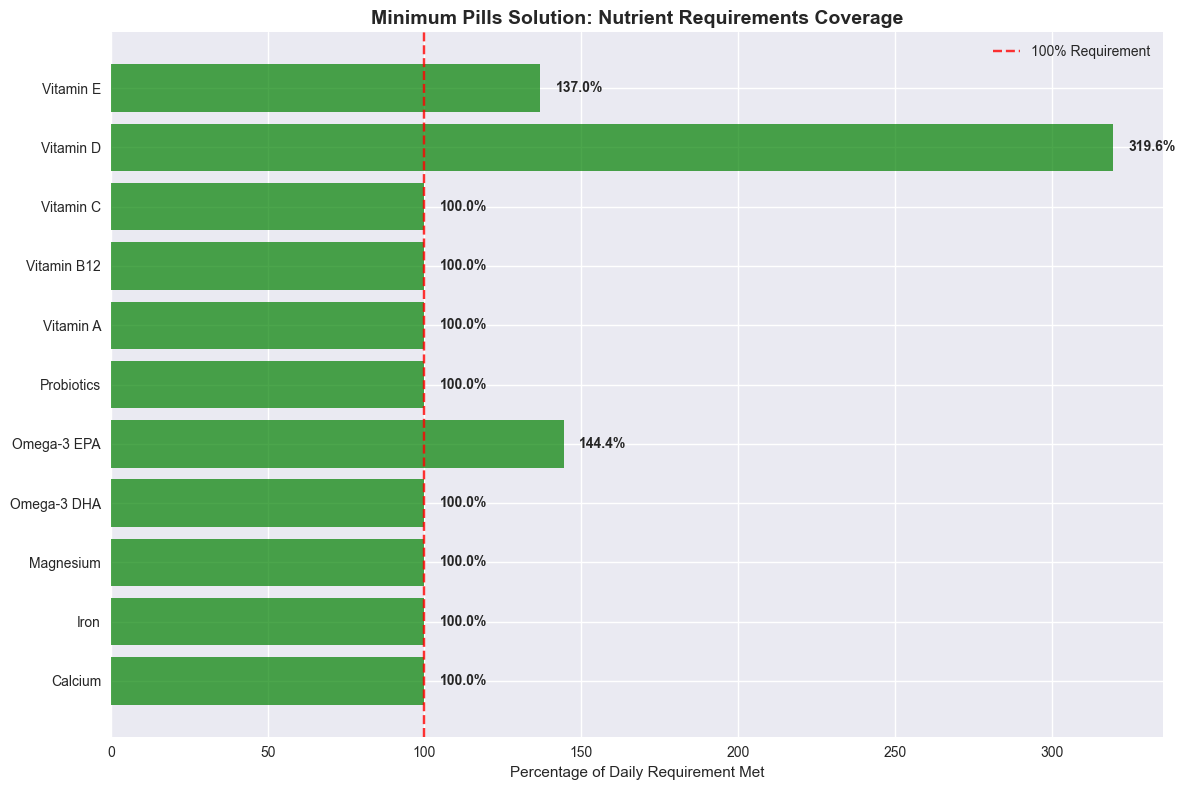

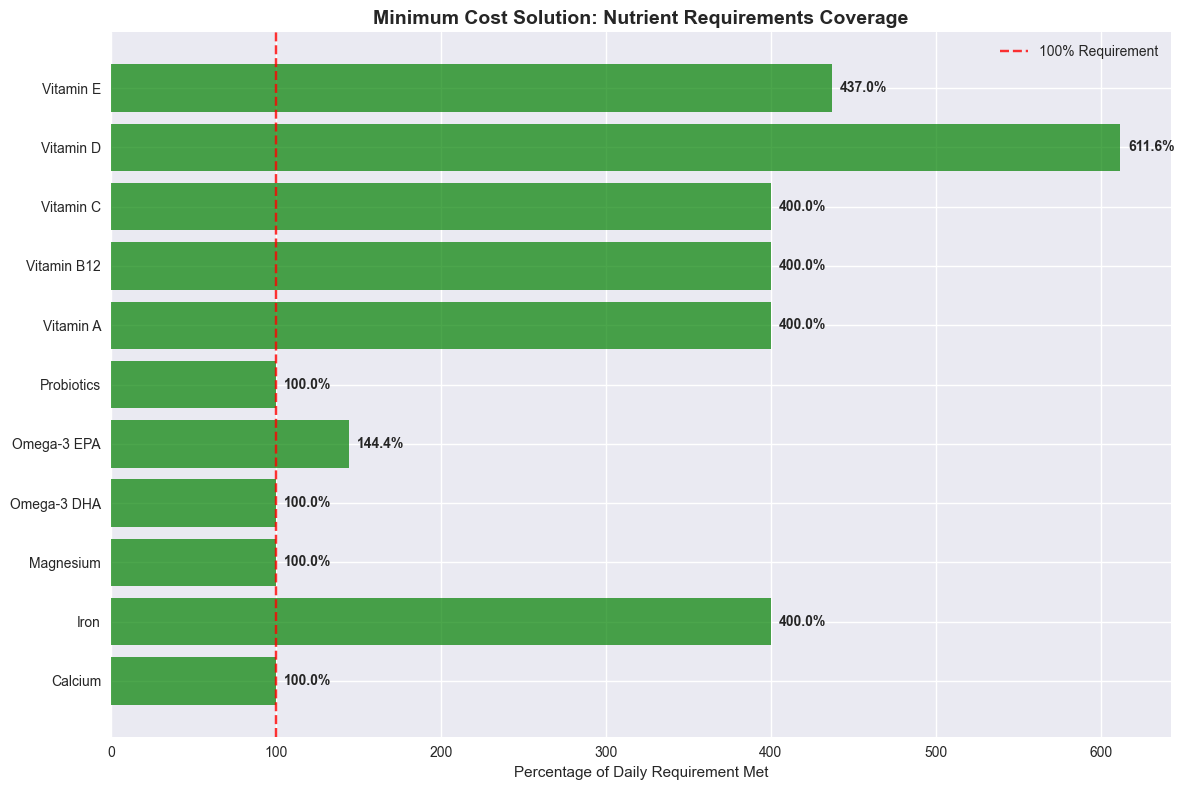

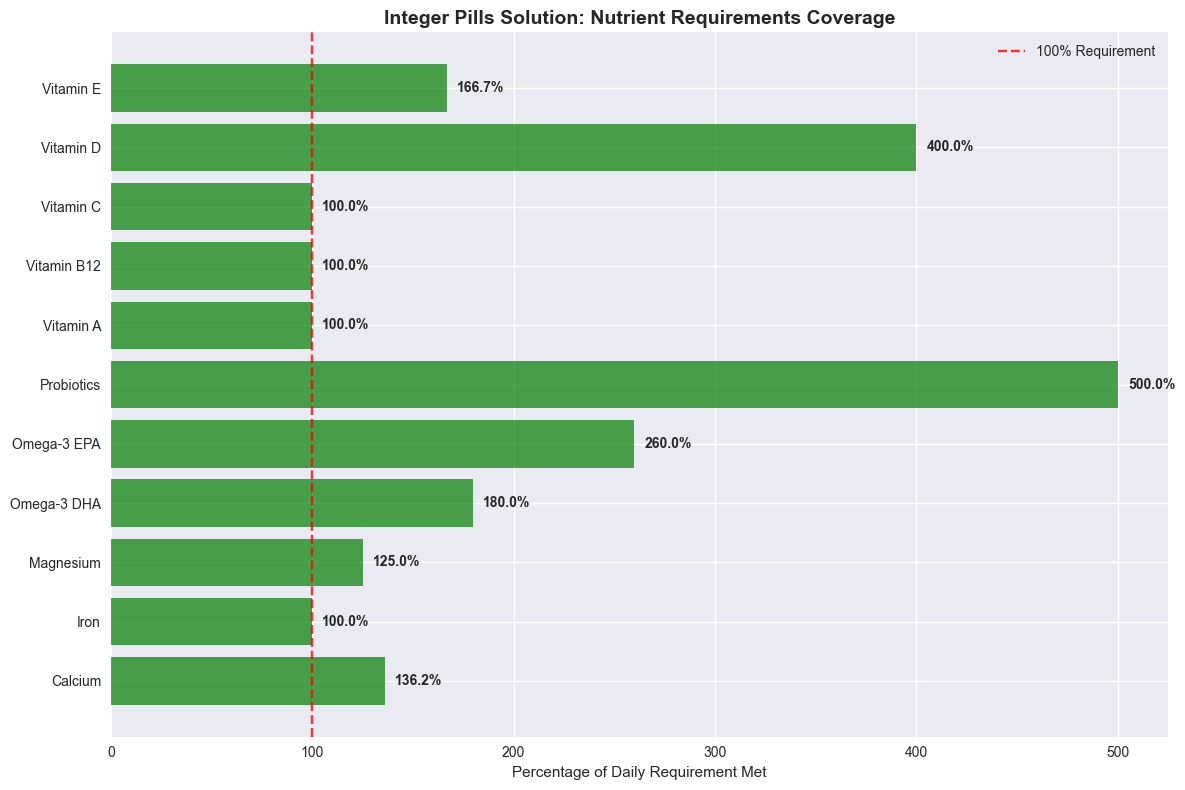

In [12]:
# Visualize nutrient coverage for each scenario
print("🔬 Nutrient Coverage Analysis")
print("="*40)

visualize_nutrient_analysis(result_pills, "Minimum Pills Solution")
visualize_nutrient_analysis(result_cost, "Minimum Cost Solution") 
visualize_nutrient_analysis(result_integer, "Integer Pills Solution")

## 🛠️ Custom Scenarios

Try modifying the supplements or requirements to see how the optimization changes. Here are some examples:

🏃‍♂️ CUSTOM SCENARIO: ATHLETE WITH HIGHER REQUIREMENTS
✅ Optimal solution found: 6.623 total pills/units

📋 Daily Requirements: Male, age 25
💊 Total Pills/Units: 6.623

📝 Supplement Plan:
  • 1.5 tablet(s) of NatureMade Multivitamin (tablet)
  • 1.8 capsule(s) of Nordic Naturals Omega-3 (capsule)
  • 1.8 capsule(s) of Thorne Magnesium Glycinate (capsule)
  • 1.6 tablet(s) of Kirkland Calcium + D3 (tablet)

🔬 Nutrient Analysis:
  • Calcium: 1200.0/1200 (100.0%)
  • Iron: 12.0/12 (100.0%)
  • Magnesium: 500.0/500 (100.0%)
  • Omega-3 DHA: 400.0/400 (100.0%)
  • Omega-3 EPA: 577.778/400 (144.4%) (+177.778 surplus)
  • Vitamin B12: 3.6/3.0 (120.0%) (+0.6 surplus)
  • Vitamin C: 135.0/120 (112.5%) (+15.0 surplus)
  • Vitamin D: 61.9/25 (247.6%) (+36.9 surplus)


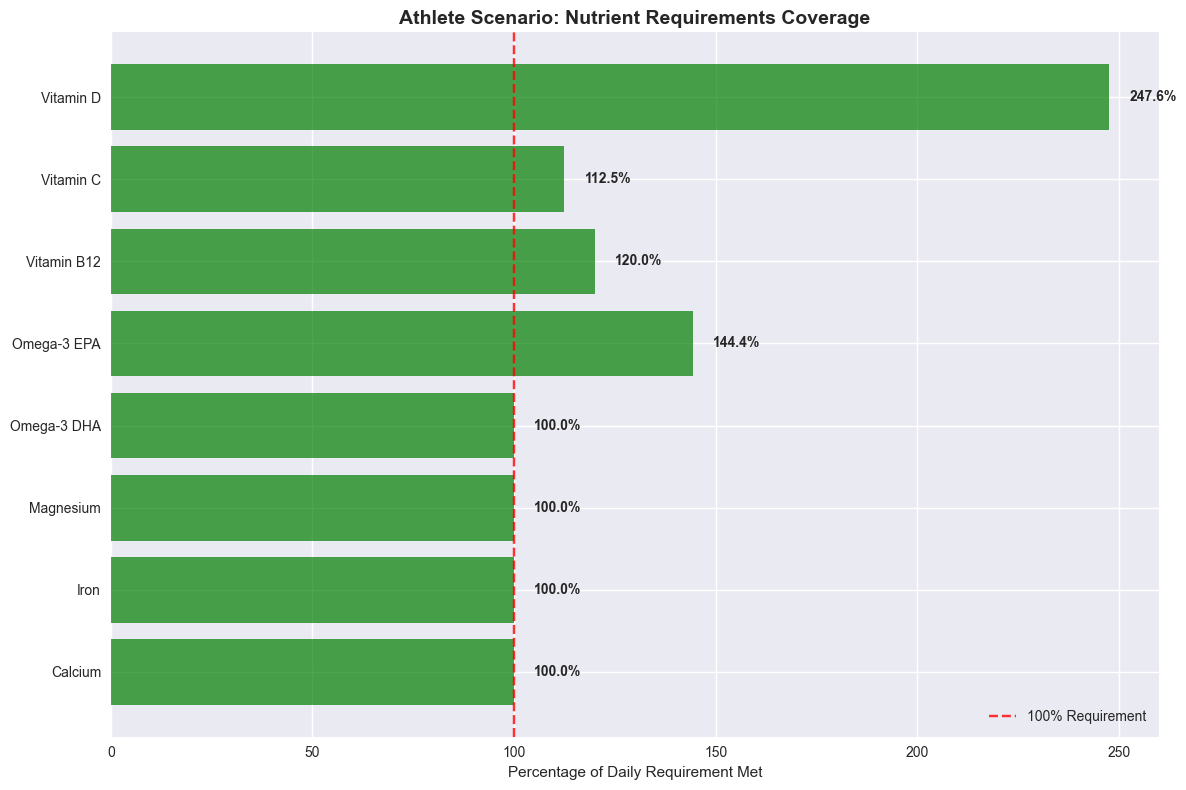

In [13]:
# Example 1: Higher protein requirements (athlete scenario)
print("🏃‍♂️ CUSTOM SCENARIO: ATHLETE WITH HIGHER REQUIREMENTS")
print("="*60)

athlete_requirements = DailyRequirement(
    age=25,
    gender="male", 
    requirements={
        "Vitamin C": 120,      # Higher due to exercise stress
        "Vitamin D": 25,       # Higher for bone health
        "Calcium": 1200,       # Higher for bone health
        "Iron": 12,            # Higher due to increased needs
        "Magnesium": 500,      # Higher for muscle function
        "Omega-3 EPA": 400,    # Higher for anti-inflammation
        "Omega-3 DHA": 400,    # Higher for brain health
        "Vitamin B12": 3.0,    # Higher for energy metabolism
    }
)

# Create new optimizer for athlete
athlete_optimizer = SupplementOptimizer()
athlete_optimizer.set_daily_requirements(athlete_requirements)

# Add only a subset of supplements to see the difference
selected_supplements = [supplements[0], supplements[1], supplements[2], supplements[3]]  # First 4 supplements
for supp in selected_supplements:
    athlete_optimizer.add_supplement(supp)

athlete_result = athlete_optimizer.solve_minimum_pills()
athlete_optimizer.print_solution(athlete_result)

# Visualize the athlete scenario
visualize_nutrient_analysis(athlete_result, "Athlete Scenario")

In [14]:
# Example 2: Budget-constrained scenario
print("\n\n💰 CUSTOM SCENARIO: BUDGET-CONSTRAINED OPTIMIZATION")
print("="*60)

# Filter supplements under $0.50 per unit
budget_supplements = [supp for supp in supplements if supp.cost_per_unit <= 0.50]

print(f"Budget supplements (≤$0.50/unit): {len(budget_supplements)}")
for supp in budget_supplements:
    print(f"  • {supp} - ${supp.cost_per_unit:.2f}")

# Create budget optimizer
budget_optimizer = SupplementOptimizer()
budget_optimizer.set_daily_requirements(daily_req)  # Use original requirements

for supp in budget_supplements:
    budget_optimizer.add_supplement(supp)

budget_result = budget_optimizer.solve_minimum_cost()
budget_optimizer.print_solution(budget_result)

# Compare with original cost-optimized solution
print(f"\n📊 COMPARISON:")
print(f"Original solution: ${result_cost['total_cost']:.2f}")
print(f"Budget solution: ${budget_result.get('total_cost', 'N/A')}")
if 'total_cost' in budget_result:
    savings = result_cost['total_cost'] - budget_result['total_cost']
    print(f"Savings: ${savings:.2f} ({(savings/result_cost['total_cost']*100):.1f}% less)")



💰 CUSTOM SCENARIO: BUDGET-CONSTRAINED OPTIMIZATION
Budget supplements (≤$0.50/unit): 5
  • NatureMade Multivitamin (tablet) - $0.15
  • Thorne Magnesium Glycinate (capsule) - $0.45
  • Kirkland Calcium + D3 (tablet) - $0.08
  • Jarrow B12 Sublingual (tablet) - $0.12
  • Gentle Iron Iron (capsule) - $0.18
❌ No feasible solution found

📊 COMPARISON:
Original solution: $1.72
Budget solution: $N/A


## 🎉 Conclusion

This notebook demonstrated how linear programming can be used to solve supplement optimization problems. Key takeaways:

### 📈 Results Summary
- **Fractional solutions** typically give the lowest pill count but may not be practical
- **Cost optimization** often leads to higher pill counts but significant cost savings
- **Integer solutions** are more practical but require more pills
- **Custom requirements** (like athletes) significantly change the optimal solution

### 🔧 Model Extensions
You can extend this model by:
- Adding maximum daily limits for nutrients (upper bounds)
- Including nutrient interaction effects  
- Adding preference weights for different supplement forms
- Supporting time-based dosing (morning vs evening)
- Integrating with real supplement databases

### 💡 Try Your Own Scenarios!
- Modify the requirements in the cells above
- Add new supplements with custom nutrient profiles
- Experiment with different optimization objectives
- Create visualizations for your custom scenarios

**Happy optimizing! 🧬💊**